# Импорты


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import lightgbm as lgb

In [3]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import (RandomForestClassifier,
                              HistGradientBoostingClassifier,
                              StackingClassifier)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from xgboost import XGBClassifier


In [4]:
#Метрики
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)


# Загрузка и обработка данных

In [5]:
data = pd.read_csv('train.csv')

#Отображение первых нескольких строк
print(data.head())


   ClientPeriod  MonthlySpending TotalSpent     Sex  IsSeniorCitizen  \
0            55            19.50    1026.35    Male                0   
1            72            25.85     1872.2    Male                0   
2             1            75.90       75.9    Male                0   
3            32            79.30       2570  Female                1   
4            60           115.25    6758.45  Female                0   

  HasPartner HasChild HasPhoneService HasMultiplePhoneNumbers  \
0        Yes      Yes             Yes                      No   
1        Yes       No             Yes                     Yes   
2         No       No             Yes                      No   
3        Yes       No             Yes                     Yes   
4        Yes      Yes             Yes                     Yes   

  HasInternetService HasOnlineSecurityService      HasOnlineBackup  \
0                 No      No internet service  No internet service   
1                 No      No interne

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

In [7]:
numeric_cols = [
    "ClientPeriod",
    "MonthlySpending",
    "TotalSpent",
]

cat_cols = [
    "HasMultiplePhoneNumbers",
    "HasInternetService",
    "HasOnlineSecurityService",
    "HasOnlineBackup",
    "HasDeviceProtection",
    "HasTechSupportAccess",
    "HasOnlineTV",
    "HasMovieSubscription",
    "HasContractPhone",
    "PaymentMethod",
]

bin_cols = [
    'Sex', 
    'HasPartner', 
    'HasChild', 
    'HasPhoneService', 
    'IsBillingPaperless'
    ]


target = 'Churn'

Столбец "TotalSpent" - имеет тип данных "object". Нужно изменить тип данных и заполнить пропущенные значения

In [8]:
data['TotalSpent'] = pd.to_numeric(data['TotalSpent'], errors='coerce')
missing = data.isnull().sum().sum()
print(f"Пропущенных значений: {missing}")

Пропущенных значений: 9


In [9]:
data['TotalSpent'] = data['TotalSpent'].fillna(0)
missing = data.isnull().sum().sum()
print(f"Пропущенных значений: {missing}")

Пропущенных значений: 0


Кодирование категориальных переменных 
* Столбцы из bin_cols - LabelEncoder
* Столбцы из cat_cols - pd.get_dummies

In [10]:
le = LabelEncoder()

for col in bin_cols:
    data[col] = le.fit_transform(data[col])

le.fit_transform(data['HasChild'])[:10]

array([1, 0, 0, 0, 1, 0, 0, 0, 1, 0])

In [11]:
data = pd.get_dummies(data, columns=cat_cols, drop_first=True, dtype=int)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 31 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   ClientPeriod                                  5282 non-null   int64  
 1   MonthlySpending                               5282 non-null   float64
 2   TotalSpent                                    5282 non-null   float64
 3   Sex                                           5282 non-null   int64  
 4   IsSeniorCitizen                               5282 non-null   int64  
 5   HasPartner                                    5282 non-null   int64  
 6   HasChild                                      5282 non-null   int64  
 7   HasPhoneService                               5282 non-null   int64  
 8   IsBillingPaperless                            5282 non-null   int64  
 9   Churn                                         5282 non-null   i

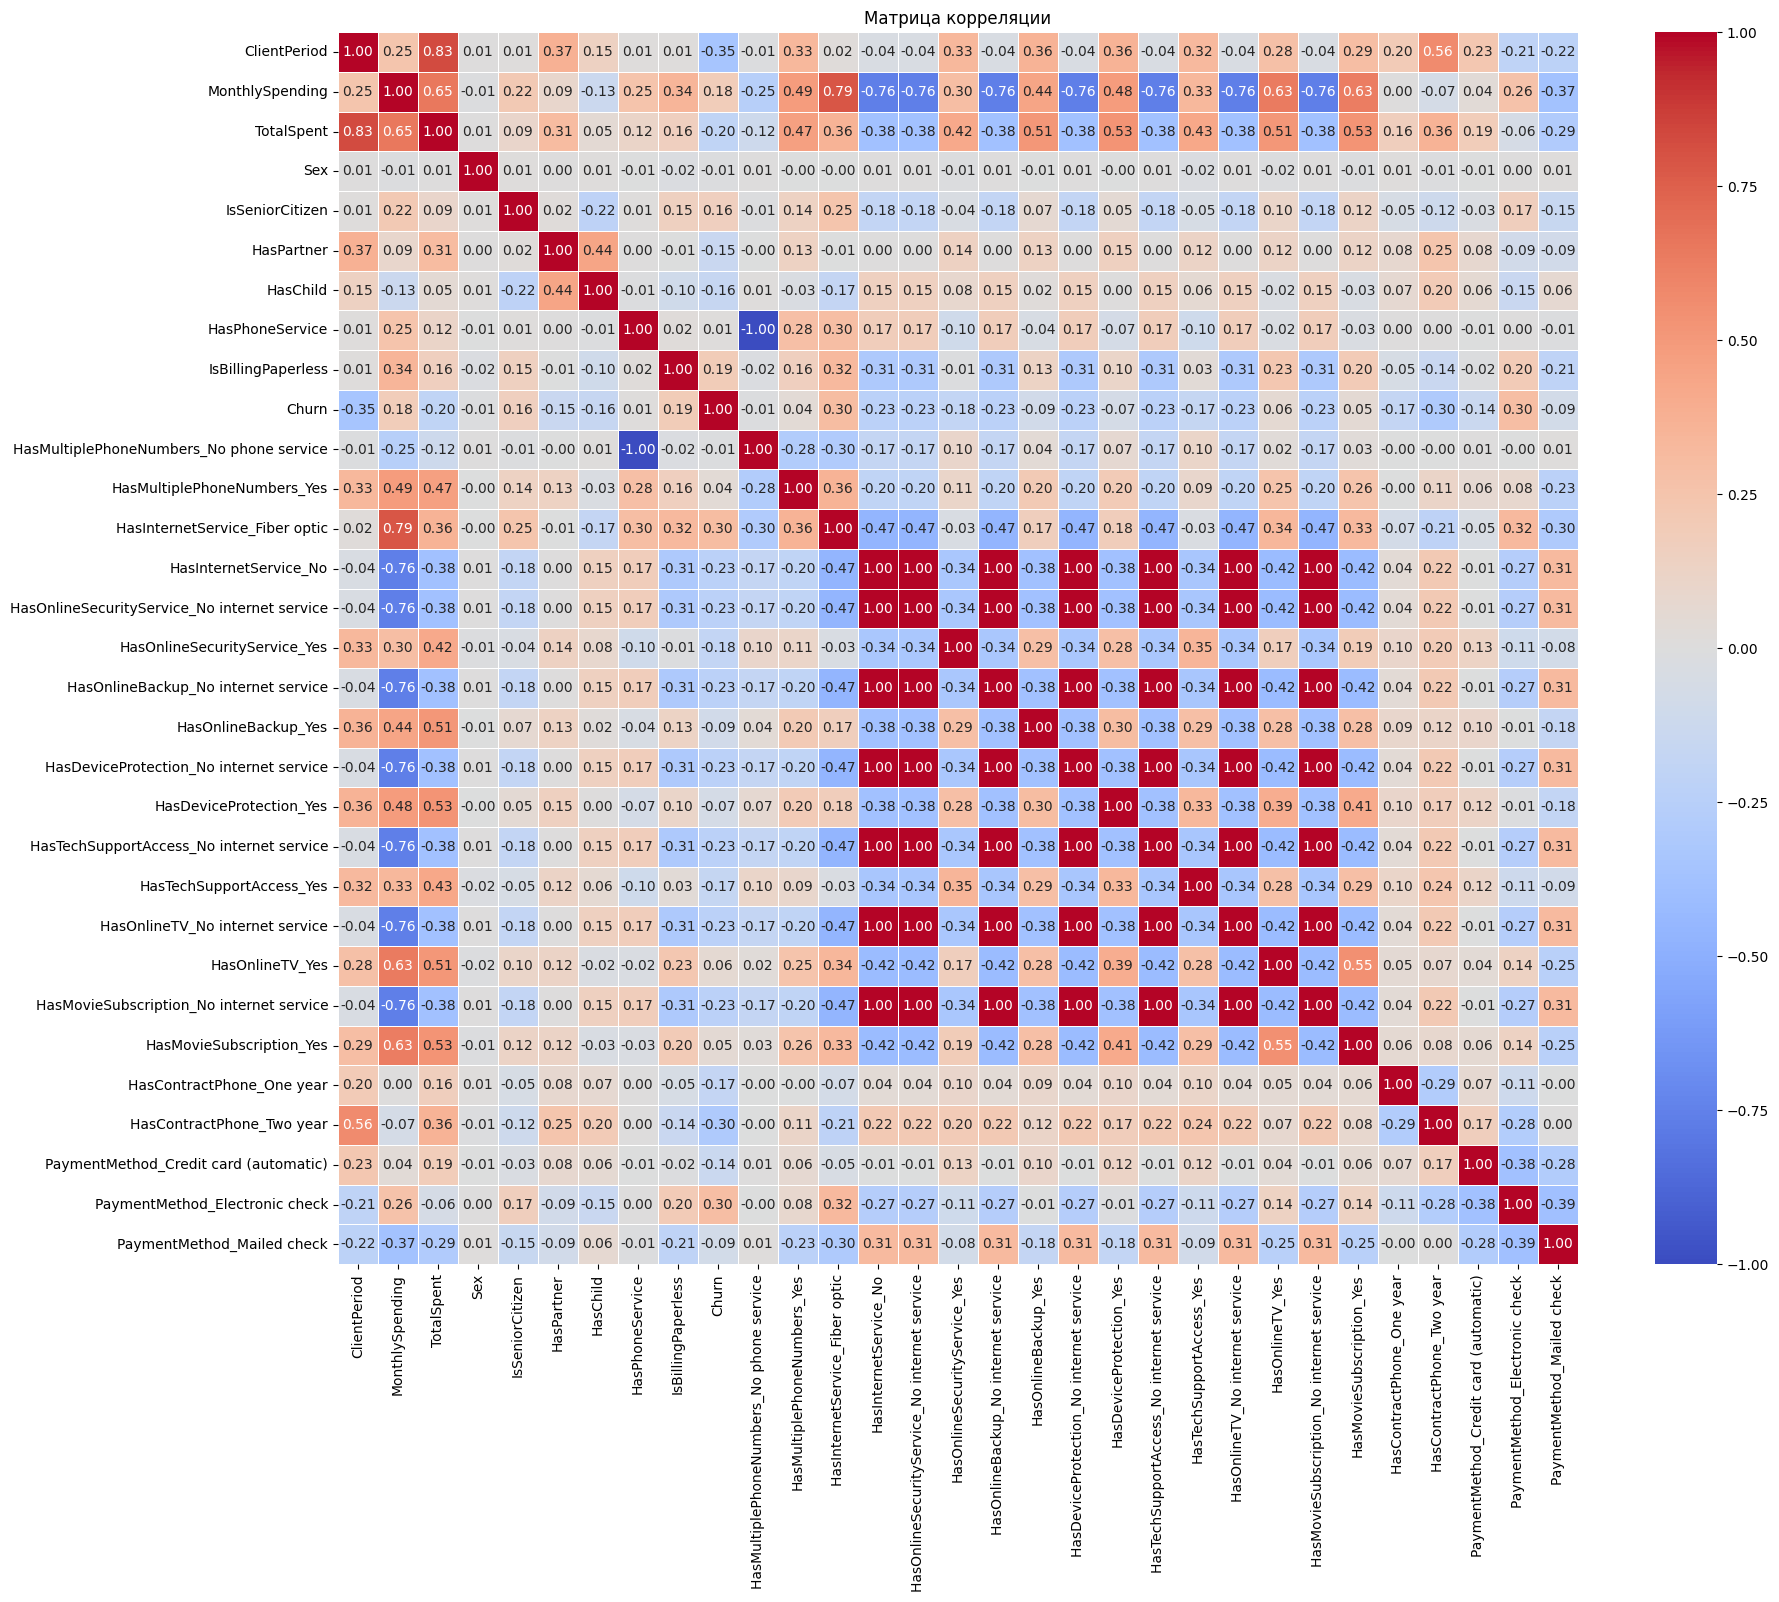

In [27]:
# Построим матрицу корреляции между признаками
correlation_matrix = data.corr()

# Визуализируем матрицу корреляции с помощью тепловой карты
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции')
plt.show()

Столбец "Churn" имеет низкую корреляцию с:
*  Sex, HasPhoneCervice, HasMiltipePhoneNumbers

ROC_AUC rf с этими признаками:  0.8557 (на тесте), 0,84928 (на kaggle)

ROC_AUC rf без этих признаками: 0.8539 (на тесте), 0,84687 (на kaggle)


In [12]:
X = data.drop(['Churn', 
              'Sex', 
             'HasMultiplePhoneNumbers_No phone service', 
             'HasMultiplePhoneNumbers_Yes',
             'HasPhoneService'
                 ], axis =1)
y = data['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[['TotalSpent', 'ClientPeriod', 'MonthlySpending']])
X_test_scaled = scaler.transform(X_test[['TotalSpent', 'ClientPeriod', 'MonthlySpending']])


print('Первый признак ДО масштабирования:')
print(f' mean={X_train.iloc[:,0].mean():.4f}, std={X_train.iloc[:,0].std():.4f}')
print("\nПервый признак ПОСЛЕ масштабирования:")
print(f"  mean={X_train_scaled[:, 0].mean():.4f}, std={X_train_scaled[:, 0].std():.4f}")

Первый признак ДО масштабирования:
 mean=32.2637, std=24.5136

Первый признак ПОСЛЕ масштабирования:
  mean=0.0000, std=1.0000


In [14]:
# Столбцы, которые были стандартизированы
scaled_cols = ['TotalSpent',  'ClientPeriod', 'MonthlySpending']

# Превращаем scaled массив обратно в DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=scaled_cols, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=scaled_cols, index=X_test.index)
# Остальные столбцы (0/1) из X_train
X_train_rest = X_train.drop(scaled_cols, axis=1)
X_test_rest = X_test.drop(scaled_cols, axis=1)
# Объединяем
X_train_final = pd.concat([X_train_scaled_df, X_train_rest], axis=1)
X_test_final = pd.concat([X_test_scaled_df, X_test_rest], axis=1)

# Random Forest 

Что повлияло на рост метрики ROC-AUC Random Forest:
* GridSearch +0,03,  GridSearch  подобрал параметры лучше, чем   Optuna
* убрананы незначительные признаки (Sex,HasMultiplePhoneNumbers, HasPhoneService в обучении, но большее кол-во признаков при обработки тестовых данных!! ) +0,001
* классы несбалансированы, SMOTE,SMOTE с Undersampling  - дал отрицательный прирост
![fdfdf](%D0%A1%D0%BD%D0%B8%D0%BC%D0%BE%D0%BA%20%D1%8D%D0%BA%D1%80%D0%B0%D0%BD%D0%B0%202026-04-12%20121437.png)

In [106]:


rf = RandomForestClassifier(n_estimators=300,
                           criterion='gini',
                           max_depth=8,
                           min_samples_leaf=10, 
                           random_state=42, 
                           bootstrap=True,
                           max_features='sqrt',
                           class_weight='balanced')
rf.fit(X_train_final, y_train)
y_pred_rf = rf.predict(X_test_final)

print('Истинные метки(первые 10):         ', list(y_test[:10]))
print('Randomn forest  :                  ', list(y_pred_rf[:10]))

f1_score(y_test, y_pred_rf)
print(f"F1 score: {f1_score(y_test, y_pred_rf):.4f}")

proba_rf = rf.predict_proba(X_test_final)

roc_value = roc_auc_score(y_test, proba_rf[:, 1])
print(f"ROC AUC: {roc_value:.4f}")

Истинные метки(первые 10):          [0, 0, 0, 1, 0, 0, 0, 0, 1, 0]
Randomn forest  :                   [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0)]
F1 score: 0.6437
ROC AUC: 0.8539


Пробуем улучшать:
* подбор гиперпараметров (дало прирост метрики)
* SMOTE (отрицательный прирост метрики)
* фильтрация признаков (дало прирост )

In [35]:
param_grid_rf = {'n_estimators': [100, 200, 300], 'max_depth': [5, 8, 10], 'min_samples_leaf': [10, 20, 30]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                        param_grid_rf, cv=5, scoring='roc_auc')
grid_rf.fit(X_train_final, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 8, ...], 'min_samples_leaf': [10, 20, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displaye

In [55]:
pip install optuna


   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [optuna]
   --------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5]),
        'random_state': 42,
        'class_weight': 'balanced',
        'n_jobs': -1,
    }
    model = RandomForestClassifier(**params)
    score = cross_val_score(model, X_train_final, y_train,
                            cv=5, scoring='roc_auc', n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=80, show_progress_bar=True)

print(f"Best ROC AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-04-12 12:28:21,034] A new study created in memory with name: no-name-3eff7edd-7dcf-4c2f-bac8-763e729875ac


  0%|          | 0/80 [00:00<?, ?it/s]

[I 2026-04-12 12:28:38,476] Trial 0 finished with value: 0.8414221050205976 and parameters: {'n_estimators': 350, 'max_depth': 14, 'min_samples_leaf': 16, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8414221050205976.
[I 2026-04-12 12:28:42,011] Trial 1 finished with value: 0.8413952240827655 and parameters: {'n_estimators': 500, 'max_depth': 14, 'min_samples_leaf': 14, 'max_features': 'log2'}. Best is trial 0 with value: 0.8414221050205976.
[I 2026-04-12 12:28:44,642] Trial 2 finished with value: 0.8414980320666299 and parameters: {'n_estimators': 150, 'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.8414980320666299.
[I 2026-04-12 12:28:48,239] Trial 3 finished with value: 0.841341831525941 and parameters: {'n_estimators': 500, 'max_depth': 7, 'min_samples_leaf': 33, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.8414980320666299.
[I 2026-04-12 12:28:48,969] Trial 4 finished with value: 0.8415750277150197 and parameters:

In [57]:
from optuna.importance import get_param_importances

importances = get_param_importances(study)
for k, v in importances.items():
    print(f"{k}: {v:.4f}")

optuna.visualization.plot_param_importances(study)

max_depth: 0.5962
max_features: 0.3516
n_estimators: 0.0287
min_samples_leaf: 0.0235


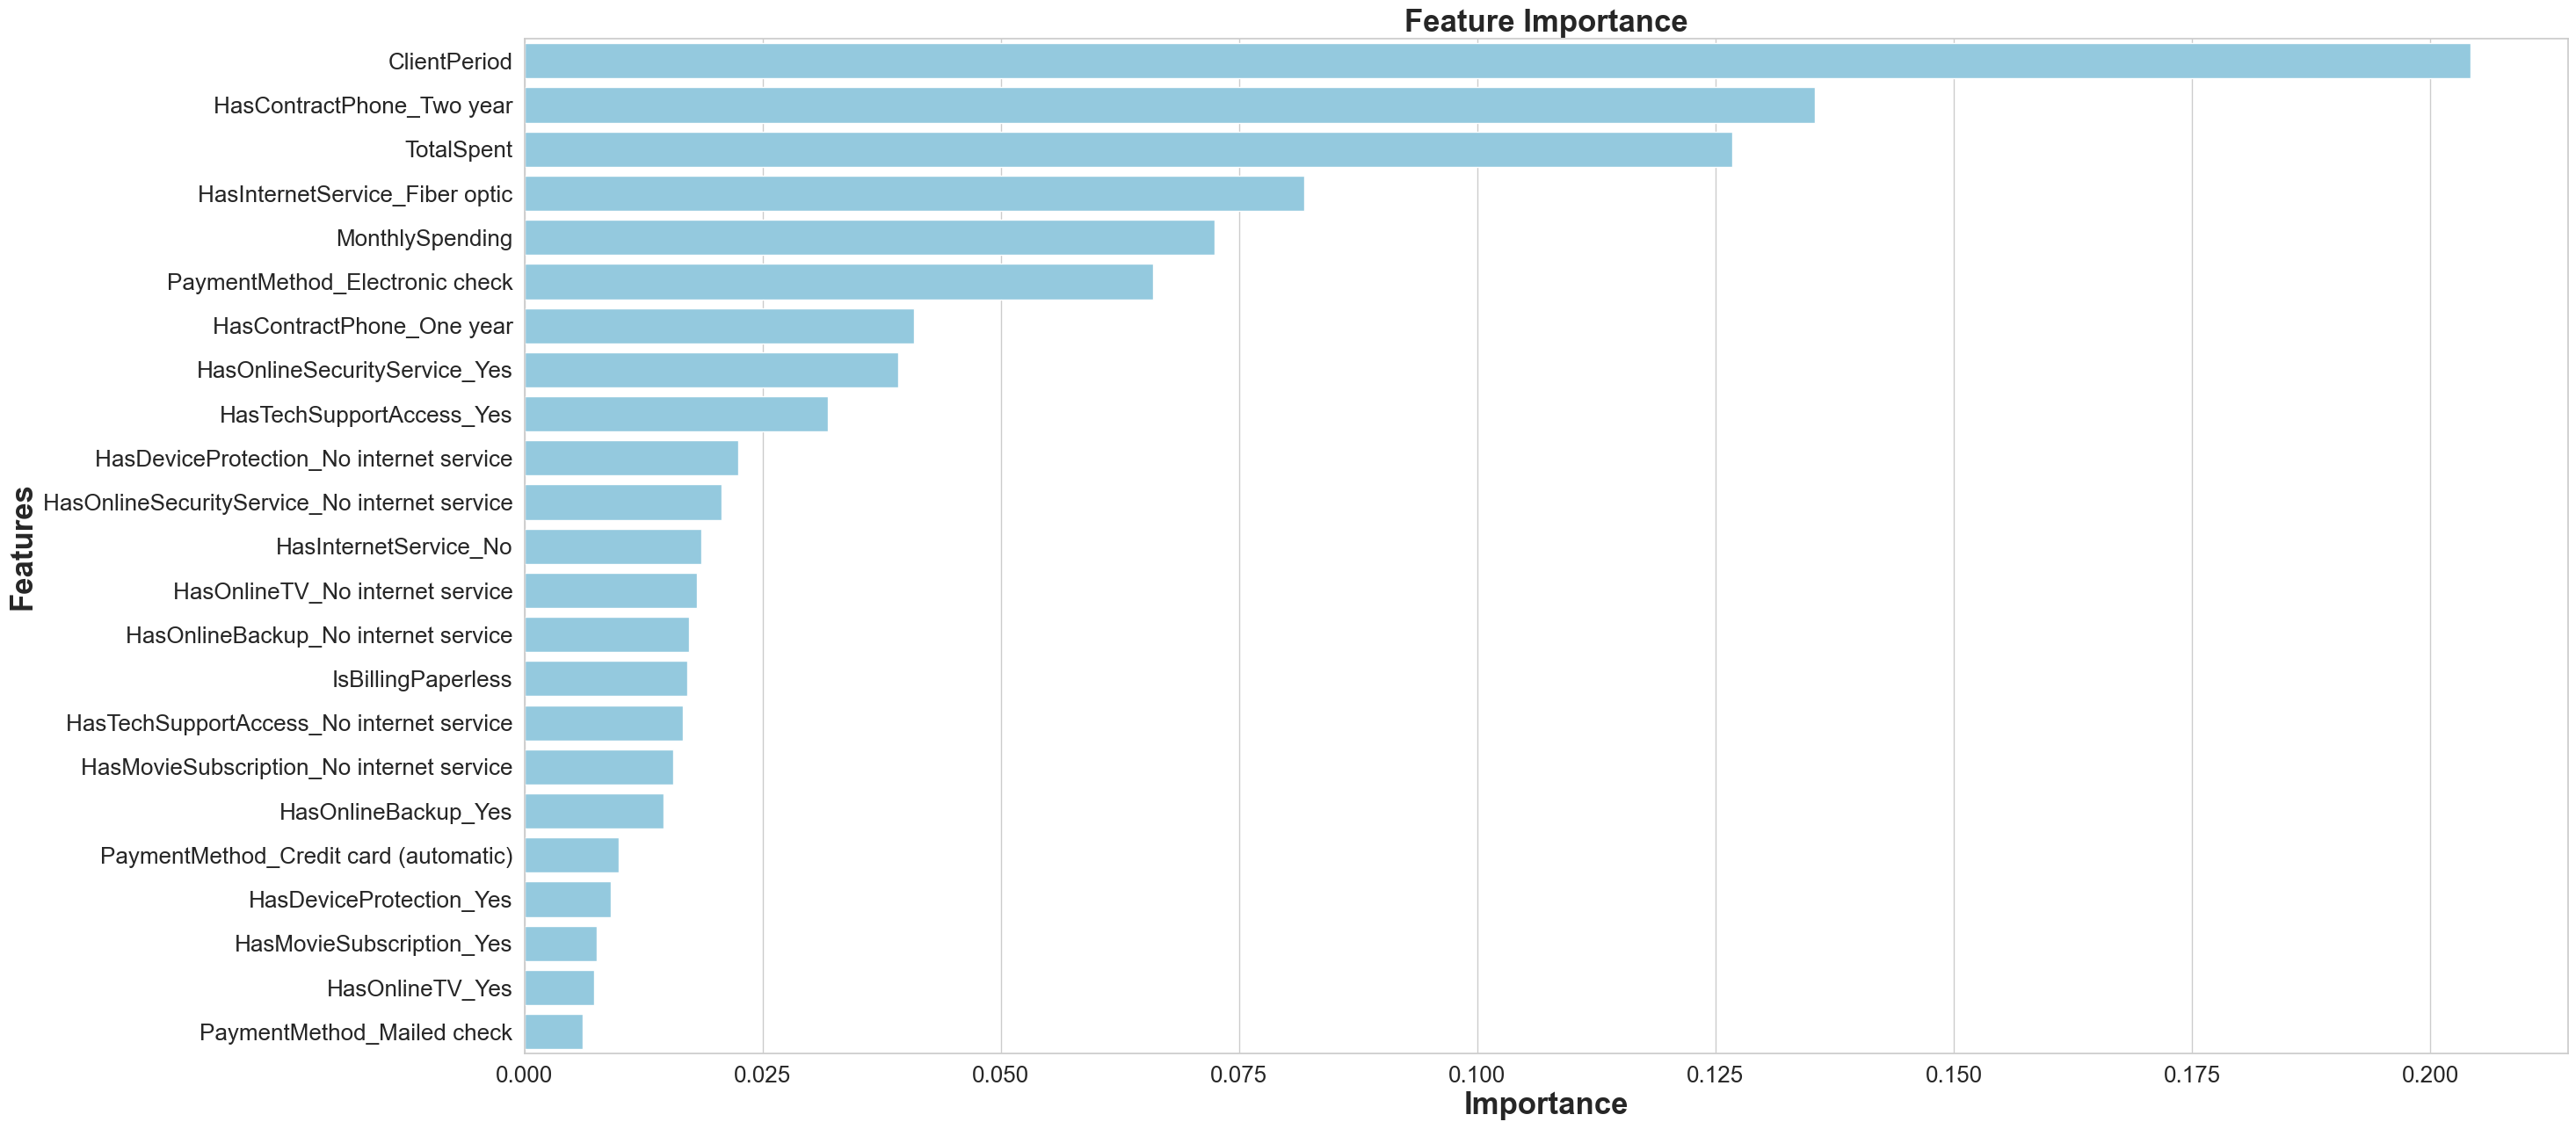

None

,Features,Gini-Importance
0,ClientPeriod,0.204229
1,HasContractPhone_Two year,0.135437
2,TotalSpent,0.126769
3,HasInternetService_Fiber optic,0.081866
4,MonthlySpending,0.072453
5,PaymentMethod_Electronic check,0.066000
6,HasContractPhone_One year,0.040935
7,HasOnlineSecurityService_Yes,0.039205
8,HasTechSupportAccess_Yes,0.031840
9,HasDeviceProtection_No internet service,0.022426


In [67]:
feats = {}
for feature, importance in zip(X_train_final.columns, rf.feature_importances_):
    feats[feature] = importance
importances = pd.DataFrame.from_dict(feats, orient='index').rename(columns={0: 'Gini-Importance'})
importances = importances.sort_values(by='Gini-Importance', ascending=False)
importances = importances.reset_index()
importances = importances.rename(columns={'index': 'Features'})
sns.set(font_scale = 5)
sns.set(style="whitegrid", color_codes=True, font_scale = 1.7)
fig, ax = plt.subplots()
fig.set_size_inches(30,15)
sns.barplot(x=importances['Gini-Importance'], y=importances['Features'], data=importances, color='skyblue')
plt.xlabel('Importance', fontsize=25, weight = 'bold')
plt.ylabel('Features', fontsize=25, weight = 'bold')
plt.title('Feature Importance', fontsize=25, weight = 'bold')
display(plt.show())
display(importances)

SMOTE

In [98]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline


In [101]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('under', RandomUnderSampler(random_state=42))
])

In [102]:
X_train_resampled, y_train_resampled = pipeline.fit_resample(X_train_final, y_train)

Загрузка данных для Kaggle

In [104]:
df_test_data = pd.read_csv('test.csv')

In [105]:
X_submit = pd.read_csv('test.csv')
submission = pd.DataFrame()
submission['Id'] = X_submit.index          # берём индекс из X_test


# 1. LabelEncoder для бинарных столбцов
binary_cols = ['Sex', 'HasPartner', 'HasChild', 'HasPhoneService', 'IsBillingPaperless']
le = LabelEncoder()
for col in binary_cols:
    X_submit[col] = le.fit_transform(X_submit[col])

# 2. TotalSpent -> numeric
X_submit['TotalSpent'] = pd.to_numeric(X_submit['TotalSpent'], errors='coerce')
X_submit['TotalSpent'] = X_submit['TotalSpent'].fillna(0)

# 3. get_dummies для мультикатегориальных
multi_cols = [
    'HasMultiplePhoneNumbers', 'HasInternetService', 'HasOnlineSecurityService',
    'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupportAccess',
    'HasOnlineTV', 'HasMovieSubscription', 'HasContractPhone', 'PaymentMethod'
]
X_submit = pd.get_dummies(X_submit, columns=multi_cols, drop_first=True, dtype=int)

X_submit.drop(['Sex', 'HasPartner', 'HasChild', 'HasPhoneService', 'IsSeniorCitizen'], axis =1)

# 4. Выровнять столбцы — добавить отсутствующие, убрать лишние
train_cols = X_train_final.columns
for c in train_cols:
    if c not in X_submit.columns:
        X_submit[c] = 0
X_submit = X_submit[train_cols]

# 5. Масштабирование числовых
scaled_cols = ['TotalSpent', 'ClientPeriod', 'MonthlySpending']
X_submit[scaled_cols] = scaler.transform(X_submit[scaled_cols])

# 6. Предсказание
submission['Churn'] = rf.predict_proba(X_submit)[:, 1]
submission.to_csv('my_submission_rf.csv', index=False)   # index=False !

# XGBoost

In [15]:
import xgboost as xgb

In [25]:
xgb_model = xgb.XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_estimators=100, learning_rate=0.01
)
xgb_model.fit(X_train_final, y_train)

y_pred_xgb = xgb_model.predict(X_test_final)

print("Истинные метки (первые 10):         ", list(y_test[:10]))
print("XGBoost predict (первые 10):        ", list(y_pred_xgb[:10]))

f1_xgb = f1_score(y_test, y_pred_xgb)
print(f"F1 score: {f1_xgb:.4f}")

proba_xgb = xgb_model.predict_proba(X_test_final)
roc_value = roc_auc_score(y_test, proba_xgb[:, 1])
print(f"ROC AUC: {roc_value:.4f}")

Истинные метки (первые 10):          [0, 0, 0, 1, 0, 0, 0, 0, 1, 0]
XGBoost predict (первые 10):         [np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
F1 score: 0.3173
ROC AUC: 0.8469


In [26]:
df_test_data = pd.read_csv('test.csv')

In [27]:
X_submit = pd.read_csv('test.csv')
submission = pd.DataFrame()
submission['Id'] = X_submit.index          # берём индекс из X_test


# 1. LabelEncoder для бинарных столбцов
binary_cols = ['Sex', 'HasPartner', 'HasChild', 'HasPhoneService', 'IsBillingPaperless']
le = LabelEncoder()
for col in binary_cols:
    X_submit[col] = le.fit_transform(X_submit[col])

# 2. TotalSpent -> numeric
X_submit['TotalSpent'] = pd.to_numeric(X_submit['TotalSpent'], errors='coerce')
X_submit['TotalSpent'] = X_submit['TotalSpent'].fillna(0)

# 3. get_dummies для мультикатегориальных
multi_cols = [
    'HasMultiplePhoneNumbers', 'HasInternetService', 'HasOnlineSecurityService',
    'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupportAccess',
    'HasOnlineTV', 'HasMovieSubscription', 'HasContractPhone', 'PaymentMethod'
]
X_submit = pd.get_dummies(X_submit, columns=multi_cols, drop_first=True, dtype=int)

X_submit.drop(['Sex', 'HasPartner', 'HasChild', 'HasPhoneService', 'IsSeniorCitizen'], axis =1)

# 4. Выровнять столбцы — добавить отсутствующие, убрать лишние
train_cols = X_train_final.columns
for c in train_cols:
    if c not in X_submit.columns:
        X_submit[c] = 0
X_submit = X_submit[train_cols]

# 5. Масштабирование числовых
scaled_cols = ['TotalSpent', 'ClientPeriod', 'MonthlySpending']
X_submit[scaled_cols] = scaler.transform(X_submit[scaled_cols])

# 6. Предсказание
submission['Churn'] = xgb_model.predict_proba(X_submit)[:, 1]
submission.to_csv('my_submission_XG.csv', index=False)   # index=False !